# Functional Software Measurement of the Teleportation Protocol

The code is based off this page of the Qiskit documentation :
- https://quantum.cloud.ibm.com/learning/en/modules/computer-science/quantum-teleportation

Textual requiremetns have been extracted from the following page of the Qiskit documentation:
- https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/quantum-teleportation

In [11]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np


secret = QuantumRegister(1, "Q")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B") 
# No CFP

cr = ClassicalRegister(3, "c") 
# No CFP

qc = QuantumCircuit(secret, Alice, Bob, cr) 
# No CFP

### Requirement 1: 
We assume that Alice and Bob share an e-bit: Alice holds a qubit $\mathsf{A},$ Bob holds a qubit $\mathsf{B},$ and together the pair $(\mathsf{A},\mathsf{B})$ is in the state $\vert\phi^+\rangle.$

In [12]:
qc.h(Alice) # 1 Entry for functional process H, + 1 Exit
qc.cx(Alice, Bob) # 2 Entries for functional process CNOT, + 1 Exit for Bob

qc.barrier() # no CFP

np.random.seed(42)
theta = np.random.uniform(0.0, 1.0) * np.pi
varphi = np.random.uniform(0.0, 2.0) * np.pi # no CFP

### Requirement 2:
Alice then comes into possession of a third qubit $\mathsf{Q}$ that she wishes to transmit to Bob.
The state of the qubit $\mathsf{Q}$ is considered to be *unknown* to Alice and Bob, and no assumptions are made about it.

In [13]:
qc.u(theta, varphi, 0.0, secret) # 1 Entry for the functional process U on entry `secret`, + 1 Exit for secret
qc.barrier() # no CFP

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

### Requirement 3:
Alice performs a controlled-NOT operation on the pair $(\mathsf{A},\mathsf{Q}),$ with $\mathsf{Q}$ being the control and $\mathsf{A}$ being the target, and then performs a Hadamard operation on $\mathsf{Q}.$

In [14]:
qc.cx(secret, Alice) # 2 Entries for func proc CNOT, + 1 Exit for Alice
qc.h(secret) # 1 Entry for func proc H, 1 Exit for secret
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

### Requirement 4:
Alice then measures both $\mathsf{A}$ and $\mathsf{Q},$ with respect to a standard basis measurement in both cases, and transmits the classical outcomes to Bob. Let us refer to the outcome of the measurement of $\mathsf{A}$ as $c_1$ and the outcome of the measurement of $\mathsf{Q}$ as $c_0$.

In [15]:
qc.measure(Alice, cr[1]) # 1 Entry Alice + 1 Write for func proc measure
qc.measure(secret, cr[0]) # 1 Write for measurement

qc.barrier() # no CFP

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "Q"), index=0>, <Qubit register=(1, "A"), index=0>, <Qubit register=(1, "B"), index=0>), clbits=())

### Requirement 5:
Bob receives $c_1$ and $c_0$ from Alice, and depending on the values of these bits he performs these operations:

   * If $c_1 = 1,$ then Bob performs a bit flip (or $X$ gate) on his qubit $\mathsf{B}.$
   * If $c_0 = 1,$ then Bob performs a phase flip (or $Z$ gate) on his qubit $\mathsf{B}.$

   That is, conditioned on $c_1c_0$ being $00,$ $01,$ $10,$ or $11,$ Bob performs one of the operations $\mathbb{I},$ $Z,$ $X,$ or $ZX$ on the qubit $\mathsf{B}.$

In [ ]:
with qc.if_test((cr[1], 1)): # 1 Read, `if_test` is a func proc, + 1 Entry for the trigger "System", + 1 Exit 
    qc.x(Bob) # 1 Entry for func proc X, triggered by if_test
with qc.if_test((cr[0], 1)): # 1 Read, `if_test` is a func proc, + 1 Entry for the trigger "System", + 1 Exit 
    qc.z(Bob) # 1 Entry for func proc Z, triggered by if_test

qc.barrier() # no CFP

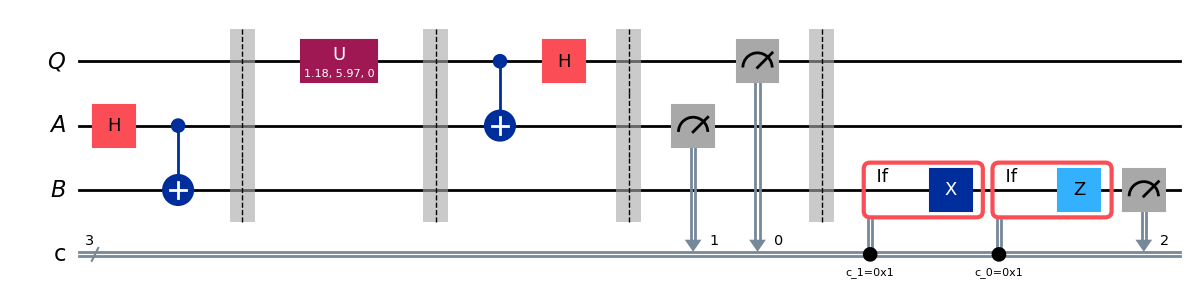

In [17]:
qc.measure(Bob, cr[2]) # We removed the u.inverse, because we mean to measure the Encoded message (state) # +1 Entry (Bob) 1 Write for measurement, then 1 Read

qc.draw(output="mpl") 